# Chapter 11 — The Chi-Square Distribution

Testing whether counts fit a claim, and whether two variables are independent.

| Section | What it covers |
|---|---|
| 11.1 | Goodness of fit |
| 11.2 | Test of independence |

**How to use this notebook.** Read a short explanation, run the worked cell under it, then do the
**Your turn** cell yourself. The worked cells already show their output, so you can check your
answer against them. Nothing here is graded and nothing is hidden, so break things freely and
re-run the setup cell if you get lost.

The matching page on the website is [The Chi-Square Distribution](https://khh-aka-lucifer.github.io/statLab/chapters/chi-square/), where the same ideas are
sliders and draggable points instead of code. Use both. The website builds the intuition, and the
notebook shows you how to do it to data of your own.

In [1]:
# Run me first. Everything below needs this cell.
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# The same colours the StatLab website uses, so your charts match the demos.
C = {
    "accent": "#2E7D6B", "accent_strong": "#1F5A4D", "accent_soft": "#D9EBE5",
    "ink": "#282725", "ink_soft": "#6B6560", "line": "#E4E0DA",
    "cat1": "#2E7D6B", "cat2": "#B5763F", "cat3": "#4E7DA6",
    "cat4": "#9A5D8F", "cat5": "#8A8F3C",
    "ok": "#4C8B57", "warn": "#C06A2E",
}

plt.rcParams.update({
    "figure.figsize": (8, 4.5), "figure.dpi": 110,
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.edgecolor": C["line"], "axes.labelcolor": C["ink"],
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": C["line"], "grid.linewidth": 0.8,
    "text.color": C["ink"], "xtick.color": C["ink_soft"], "ytick.color": C["ink_soft"],
    "font.size": 11, "axes.titlesize": 12, "legend.frameon": False,
})

# Works whether you launched Jupyter inside code/ or at the repo root.
DATA = Path("data") if Path("data").exists() else Path("code/data")

# One seed, so your numbers match the text. Change it and the randomness changes with you.
rng = np.random.default_rng(12345)

print("Ready. pandas", pd.__version__, "| numpy", np.__version__)

Ready. pandas 3.0.3 | numpy 2.4.4


## Tests for counts

Everything so far tested means and proportions. The chi-square family tests **counts in categories**,
by comparing what you observed with what some claim expects,

$$\chi^2 = \sum \frac{(O - E)^2}{E}$$

Zero means a perfect match, and the statistic grows as the counts drift from the claim.

## 11.1 Goodness of fit

Does rain in Seattle care what day of the week it is? It should not. Let us test that it does not,
which makes this one of the rare textbook examples where the null hypothesis is actually true.

In [2]:
weather = pd.read_csv(DATA / "seattle-weather.csv", parse_dates=["date"])
weather["weekday"] = weather["date"].dt.day_name()

order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
rainy = weather[weather["precipitation"] > 0]["weekday"].value_counts().reindex(order)

observed = rainy.to_numpy()
expected = np.full(7, observed.sum() / 7)

table = pd.DataFrame({"observed": observed, "expected": expected.round(1),
                      "(O-E)^2/E": ((observed - expected)**2 / expected).round(3)}, index=order)
table

,observed,expected,(O-E)^2/E
Monday,91,89.0,0.045
Tuesday,96,89.0,0.551
Wednesday,88,89.0,0.011
Thursday,90,89.0,0.011
Friday,97,89.0,0.719
Saturday,77,89.0,1.618
Sunday,84,89.0,0.281


In [3]:
chi2, p = stats.chisquare(observed)

print(f"chi-square = {chi2:.4f}")
print(f"df         = {len(observed) - 1}")
print(f"p          = {p:.4f}")
print()
print(f"critical value at 5 %: {stats.chi2.ppf(0.95, 6):.3f}")
print("Our statistic is nowhere near it, so we do not reject. The rain does not read calendars.")

chi-square = 3.2360
df         = 6
p          = 0.7787

critical value at 5 %: 12.592
Our statistic is nowhere near it, so we do not reject. The rain does not read calendars.


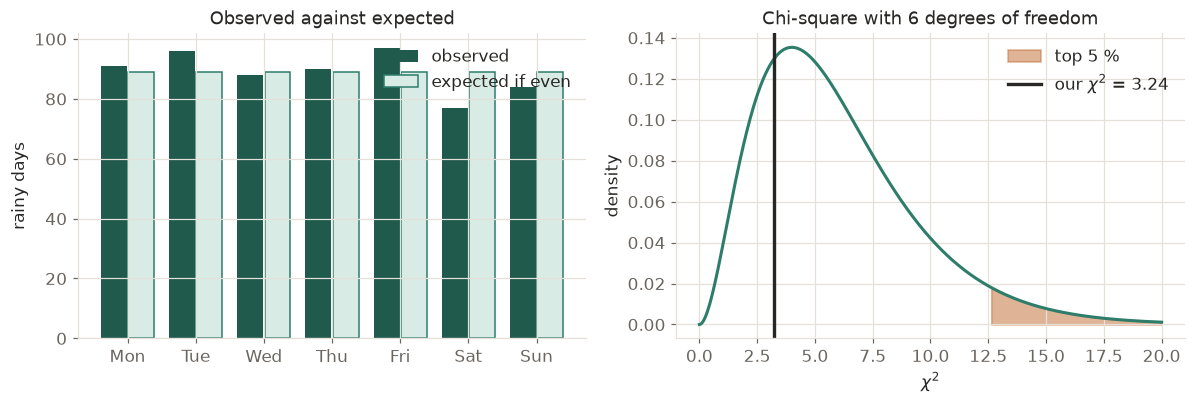

In [4]:
fig, (left, right) = plt.subplots(1, 2, figsize=(11, 3.8))

left.bar(np.arange(7) - 0.2, observed, width=0.38, color=C["accent_strong"], label="observed")
left.bar(np.arange(7) + 0.2, expected, width=0.38, color=C["accent_soft"],
         edgecolor=C["accent"], label="expected if even")
left.set_xticks(range(7)); left.set_xticklabels([d[:3] for d in order])
left.set_ylabel("rainy days"); left.set_title("Observed against expected"); left.legend()

grid = np.linspace(0, 20, 400)
right.plot(grid, stats.chi2.pdf(grid, 6), color=C["accent"], lw=2)
crit = stats.chi2.ppf(0.95, 6)
tail = grid >= crit
right.fill_between(grid[tail], stats.chi2.pdf(grid[tail], 6), color=C["warn"], alpha=0.5,
                   label="top 5 %")
right.axvline(chi2, color=C["ink"], lw=2.2, label=rf"our $\chi^2$ = {chi2:.2f}")
right.set_xlabel(r"$\chi^2$"); right.set_ylabel("density")
right.set_title("Chi-square with 6 degrees of freedom"); right.legend()

plt.tight_layout()
plt.show()

This is what "fail to reject" looks like, and it is worth seeing at least once. The observed bars
wobble around the expected ones by a few days each way, the statistic lands in the fat part of the
curve, and we conclude that nothing is going on, which happens to be the truth.

A large p-value is not evidence that $H_0$ is true. It means the data gives you no reason to doubt
it, which is a weaker and more honest statement.

In [ ]:
# Your turn.
# Test whether SNOW days are evenly spread across the four seasons.
# 1. Build the observed counts (use date.dt.month to assign seasons).
# 2. Run stats.chisquare against a uniform expectation.
# 3. This null should be wildly false. Check whether the expected counts are all at least 5,
#    which is the assumption the test needs.

...

## 11.2 Test of independence

The second use compares two categorical variables. If they are **independent**, every row of the
contingency table splits across the columns in the same proportions, and the count independence
expects in each cell is

$$E = \frac{\text{row total} \times \text{column total}}{n}$$

Back to the Titanic, where class and survival are visibly related.

In [5]:
titanic = pd.read_csv(DATA / "titanic.csv")
observed = pd.crosstab(titanic["class"], titanic["survived"])
observed.columns = ["died", "survived"]
observed

,died,survived
class,,
First,80,136
Second,97,87
Third,372,119


In [6]:
chi2, p, dof, expected = stats.chi2_contingency(observed, correction=False)

print(f"chi-square = {chi2:.4f}")
print(f"df         = {dof}   = (rows - 1) x (columns - 1) = ({observed.shape[0]-1}) x ({observed.shape[1]-1})")
print(f"p          = {p:.3e}")
print()
print("what independence would have expected:")
pd.DataFrame(expected.round(1), index=observed.index, columns=observed.columns)

chi-square = 102.8890
df         = 2   = (rows - 1) x (columns - 1) = (2) x (1)
p          = 4.549e-23

what independence would have expected:


,died,survived
class,,
First,133.1,82.9
Second,113.4,70.6
Third,302.5,188.5


In [7]:
contribution = (observed - expected)**2 / expected

print("where the statistic comes from:")
print(contribution.round(2).to_string())
print(f"\ntotal = {contribution.to_numpy().sum():.2f}")

where the statistic comes from:
         died  survived
class                  
First   21.18      34.0
Second   2.36       3.8
Third   15.95      25.6

total = 102.89


The table of contributions is more useful than the p-value. Third class contributes most, and in the
direction of more deaths than independence predicts. First class contributes in the opposite
direction. That sentence is the finding, and the p-value only licenses you to say it out loud.

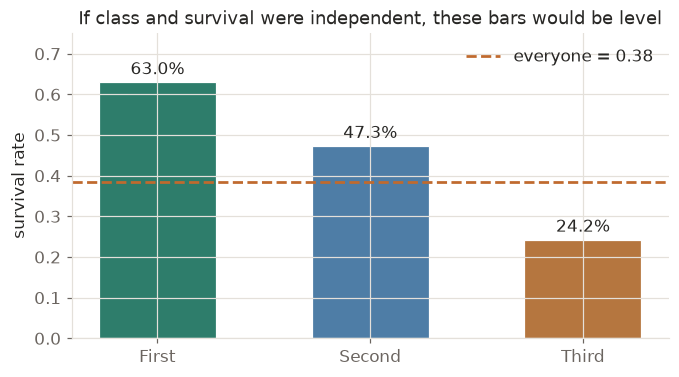

In [8]:
rates = pd.crosstab(titanic["class"], titanic["survived"], normalize="index")[1]

fig, ax = plt.subplots(figsize=(7, 3.6))
bars = ax.bar(rates.index, rates.values, width=0.55,
              color=[C["cat1"], C["cat3"], C["cat2"]], edgecolor="white", linewidth=0.8)
ax.axhline(titanic["survived"].mean(), color=C["warn"], ls="--", lw=1.8,
           label=f"everyone = {titanic['survived'].mean():.2f}")
for x, v in zip(rates.index, rates.values):
    ax.text(x, v + 0.02, f"{v:.1%}", ha="center", color=C["ink"])

ax.set_ylabel("survival rate"); ax.set_ylim(0, 0.75)
ax.set_title("If class and survival were independent, these bars would be level")
ax.legend()
plt.show()

### A warning the test needs

The chi-square approximation assumes every expected count is at least about 5. Small expected counts
make the statistic unreliable, and the fix is to combine categories or use Fisher's exact test.

In [9]:
small = pd.crosstab(titanic["deck"].fillna("unknown"), titanic["survived"])
_, _, _, exp_small = stats.chi2_contingency(small, correction=False)

print(f"smallest expected count in the deck table: {exp_small.min():.2f}")
print(f"cells below 5: {(exp_small < 5).sum()} of {exp_small.size}")
print("\nThis table should NOT be tested with chi-square as it stands.")

smallest expected count in the deck table: 1.54
cells below 5: 3 of 16

This table should NOT be tested with chi-square as it stands.


In [ ]:
# Your turn.
# Test whether embark_town and survival are independent.
# 1. Build the table, run the test, and check the expected counts first.
# 2. Look at the contribution table. Which port drives the result?
# 3. Careful: this one has a lurking variable. Which port did most Third class passengers use?
#    Chapter 17 is about exactly this trap.

...

## Exercises

1. **Simulate the null.** Shuffle the `survived` column so it is unrelated to class, rebuild the
   table, and record the chi-square. Do it 2000 times and plot the pile. It should match the
   $\chi^2(2)$ curve, and about 5 % should exceed the critical value. Check both.

2. **Sex and class.** Test whether sex and travelling class are independent. Before running it,
   predict the answer from what you know of 1912.

3. **Goodness of fit to a real distribution.** Bin Titanic `age` into decades and test whether it
   fits a normal distribution with the sample's own mean and standard deviation. Remember to subtract
   an extra degree of freedom for each parameter you estimated.

4. **Small counts.** Take the deck table from above, combine the rare decks into one "other"
   category until every expected count clears 5, then test it. Does combining change the conclusion?

5. **Chi-square and the two-proportion test.** For a 2 by 2 table, the chi-square test and the
   two-proportion z-test are the same test. Verify numerically that $\chi^2 = z^2$ using the
   sex-against-survival table from Chapter 10.

## What you should take away

Chi-square compares observed counts against the counts a claim expects, and the contribution table
tells you where the disagreement lives, which is almost always more useful than the p-value.

The Seattle weekday test is worth remembering as the shape of an honest non-result. And the
expected-count rule is a real constraint, not a formality, because the whole approximation rests on
it.

---

*StatLab, by Dr. Sein Minn and Kaung Hein Htet. Code MIT, text CC BY 4.0.
Follows OpenStax [Introductory Statistics](https://openstax.org) (Illowsky & Dean, CC BY 4.0).*